# Análise Exploratória de Dados
**Dataset:** Titanic

Neste *notebook*, vamos traduzir os conceitos teóricos de Análise Exploratória de Dados (EDA) em demonstrações práticas. O objetivo não é modelar, mas sim investigar: entender a incompletude, os tipos de dados reais *versus* os tipos em memória, desvendar estatísticas resumidas e levantar hipóteses visuais.

In [1]:
# Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px # Alternativa moderna para gráficos interativos

# Configuração visual padrão para os gráficos estáticos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carregamento do dataset Titanic (disponível nativamente no Seaborn)
df = sns.load_dataset('titanic')

## Tipos em Memória vs. Tipos Estatísticos
Uma das primeiras armadilhas da EDA é confiar cegamente nos tipos de dados que o computador atribui às variáveis. A semântica importa.

In [2]:
# Visão geral estrutural
display(df.head(3))
print("-" * 50)
df.info()

# Demonstração: 'pclass' está guardado como int64 (computacionalmente contínuo/discreto numérico),
# mas estatisticamente é uma Categórica Ordinal.
print("\nValores únicos em 'pclass':", df['pclass'].unique())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

Valores únicos em 'pclass':

## Dados Incompletos: A ausência carrega informação?
Valores nulos (`NaN`) não são meros erros. Eles contam uma história sobre a recolha dos dados.

Valores ausentes por coluna:
 age            177
embarked         2
deck           688
embark_town      2
dtype: int64


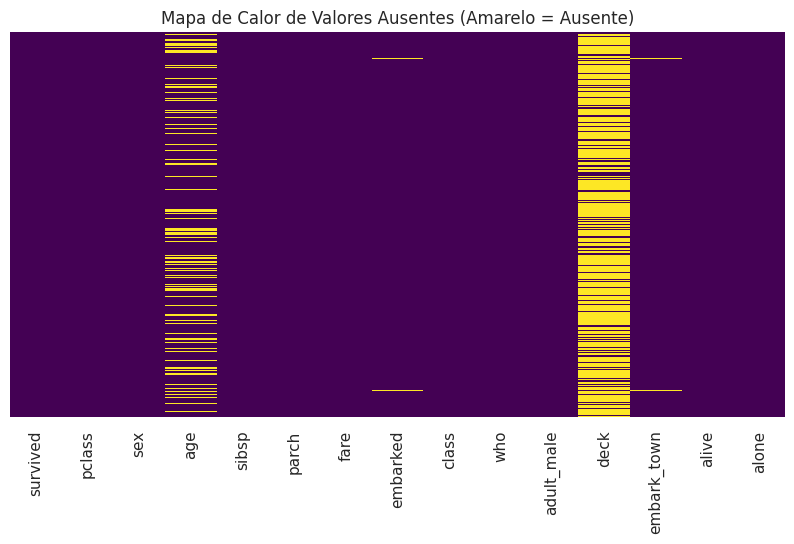

In [3]:
# Quantificação de dados ausentes
ausentes = df.isnull().sum()
print("Valores ausentes por coluna:\n", ausentes[ausentes > 0])

# Visualização da matriz de nulidade
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Ausentes (Amarelo = Ausente)')
plt.show()

# Hipótese: A cabine ('deck') tem demasiados valores ausentes. Estará relacionado com a classe do bilhete?

## Estatísticas que Enganam
Média, mediana e desvio-padrão comprimem a realidade. Vamos focar-nos na distribuição real dos dados, explorando **Variáveis Contínuas** e os conceitos de **Quantis e Boxplots**.

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64


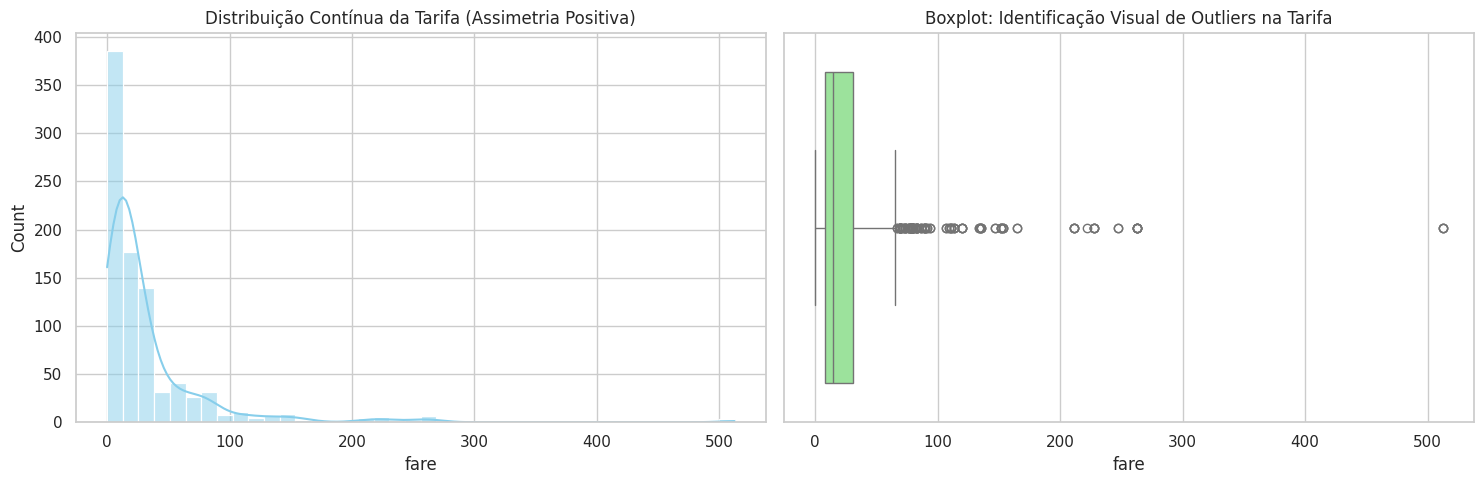

In [4]:
# Estatísticas descritivas básicas da variável 'fare' (Tarifa - Numérica Contínua)
print(df['fare'].describe())

# A média é ~32, mas o valor máximo é 512. A média está a esconder a assimetria!
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma: Visão da forma da distribuição
sns.histplot(df['fare'], bins=40, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição Contínua da Tarifa (Assimetria Positiva)')

# Boxplot: Excelente para visualizar quantis (25%, 50%, 75%) e outliers extremos
sns.boxplot(x=df['fare'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot: Identificação Visual de Outliers na Tarifa')

plt.tight_layout()
plt.show()

## Padrões Visuais como Hipóteses (Análise Multivariada)
Vamos cruzar variáveis para formular hipóteses sobre a sobrevivência. Lembramos: correlação visual não é causalidade, é o ponto de partida para a modelagem.

# Hipótese: A taxa de sobrevivência variou por Classe e Sexo?


In [5]:
# Preparar os dados para o gráfico interativo
taxa_sobrevivencia = df.groupby(['pclass', 'sex'])['survived'].mean().reset_index()

# Gráfico interativo com Plotly
fig = px.bar(taxa_sobrevivencia, x='pclass', y='survived', color='sex', barmode='group',
             labels={'pclass': 'Classe do Bilhete', 'survived': 'Taxa de Sobrevivência', 'sex': 'Sexo'},
             title='Hipótese Interativa: Taxa de Sobrevivência por Classe e Sexo',
             color_discrete_map={'male': '#1f77b4', 'female': '#e377c2'})
fig.update_layout(yaxis_tickformat='.0%')
fig.show()

### Boxplots Multivariados
Vamos juntar uma variável Contínua (`age`), uma Ordinal (`pclass`) e uma Binária (`survived`).

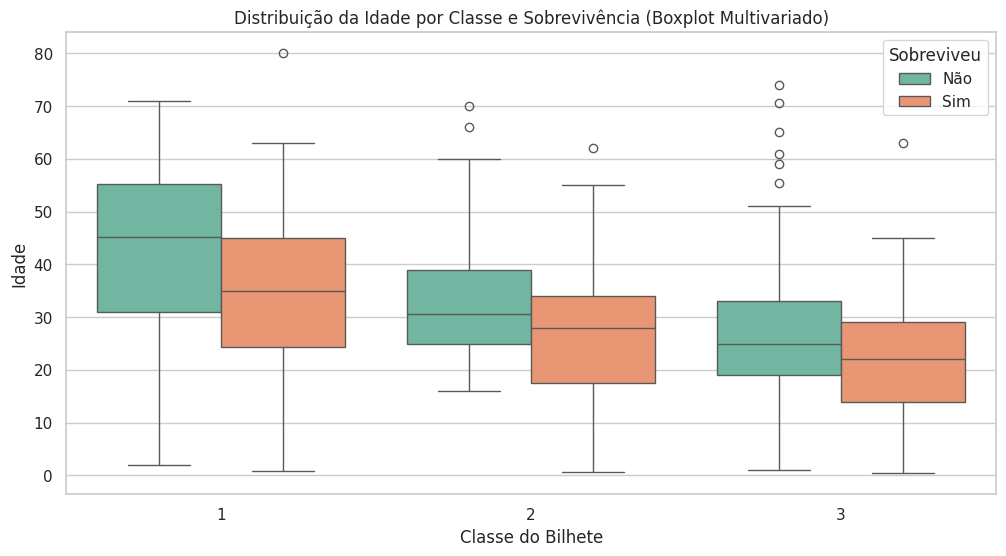

In [6]:
plt.figure(figsize=(12, 6))

# Armazenamos o objeto do eixo (ax) gerado pelo seaborn
ax = sns.boxplot(x='pclass', y='age', hue='survived', data=df, palette='Set2')

plt.title('Distribuição da Idade por Classe e Sobrevivência (Boxplot Multivariado)')
plt.xlabel('Classe do Bilhete')
plt.ylabel('Idade')

# Extraímos os 'handles' (as cores/formas) e ignoramos os rótulos originais (0 e 1)
handles, _ = ax.get_legend_handles_labels()

# Recriamos a legenda mapeando explicitamente os handles extraídos para os novos rótulos
plt.legend(handles=handles, labels=['Não', 'Sim'], title='Sobreviveu')

plt.show()

Observações:
1. Os passageiros da 1ª classe eram, em média, mais velhos.
2. Na 2ª e 3ª classes, os sobreviventes tendem a ter uma mediana de idade ligeiramente inferior (possível prioridade a crianças).

## Automação da EDA com YData Profiling
Embora a inspeção manual seja fundamental para o raciocínio crítico, na prática do dia a dia (e em *pipelines* complexos), utilizamos bibliotecas de *Automated EDA* para acelerar a deteção de valores ausentes, correlações e distribuições.

In [ ]:
!pip install ydata_profiling

In [ ]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Relatório EDA - Titanic")
profile.to_notebook_iframe()

## Exemplo Off-Topic: Datasets no Mundo Real
Este é um exemplo clássico de um *dataset* real que não possui qualquer preparo estrutural. A formatação voltada para leitura humana em planilhas dificulta a ingestão programática e a análise exploratória direta.

**Exercício**: Tente aplicar os métodos que veremos durante essa aula à este dataset e compartilhe os resultados conseguidos.



In [ ]:
# Leitura de um arquivo Excel bruto (necessita do pacote xlrd ou openpyxl)
fbi_citus_2010 = "sample_data/fbi_citus_2010.xls"
fbi_citus_2010_df = pd.read_excel(fbi_citus_2010)
display(fbi_citus_2010_df.head())

**Nota**: A exibição mostrará cabeçalhos mesclados, linhas em branco como NaN e
metadados textuais misturados com dados tabulares. O passo zero aqui seria a limpeza.